##Customer Segmentation using Clustering



Customer segmentation is a fundamental application of unsupervised learning that enables organizations to group customers based on shared characteristics and behavioral patterns. By identifying distinct customer segments, businesses can better understand their audience, tailor marketing strategies, and improve overall decision-making.


This project focuses on segmenting customers using clustering techniques based on demographic attributes such as age, income, and household composition, as well as purchasing behavior across different product categories. The dataset used contains detailed information about customer profiles and their spending patterns.


To achieve this, data preprocessing steps including handling missing values, feature engineering, and encoding of categorical variables are performed. The features are then scaled to ensure uniformity before applying clustering algorithms. The K-Means clustering algorithm is used to group customers into distinct segments, with the optimal number of clusters determined using the Elbow Method and Silhouette Score.


The resulting clusters are analyzed to derive meaningful insights about different customer groups, which can be leveraged for targeted marketing, customer retention strategies, and business optimization.

In [ ]:
import pandas as pd


In [ ]:
data= pd.read_csv("/content/customer_segmentation.csv")

In [ ]:
display(data.head())
display(data.info())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

In [ ]:
display(data.isnull().sum())

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
percent_missing = (data['Income'].isnull().sum() / len(data['Income'])) * 100
percent_missing

np.float64(1.0714285714285714)

In [ ]:
# since the missing percentage is less than 2% we replace the missing values with the mean value
mean_income = data['Income'].mean()
data['Income'] = data['Income'].fillna(mean_income)

# Verify that there are no more missing values in 'Income'
display(data['Income'].isnull().sum())

np.int64(0)

In [ ]:
print('Unique values in Education column:')
display(data['Education'].value_counts())

Unique values in Education column:


,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [ ]:
print('\nUnique values in Marital_Status column:')
display(data['Marital_Status'].value_counts())


Unique values in Marital_Status column:


,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [ ]:
data['Marital_Status'] = data['Marital_Status'].replace(['Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO'], 'Single')
print('\nUnique values in Marital_Status column after grouping:')
display(data['Marital_Status'].value_counts())


Unique values in Marital_Status column after grouping:


,count
Marital_Status,
Married,864
Single,796
Together,580


In [ ]:
# One-hot encode 'Education' and 'Marital_Status' columns
data = pd.get_dummies(data, columns=['Education', 'Marital_Status'], drop_first=False)

display(data.head())
display(data.info())

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Z_Revenue,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together
0,5524,1957,58138.0,0,0,04-09-2012,58,635,88,546,...,11,1,False,False,True,False,False,False,True,False
1,2174,1954,46344.0,1,1,08-03-2014,38,11,1,6,...,11,0,False,False,True,False,False,False,True,False
2,4141,1965,71613.0,0,0,21-08-2013,26,426,49,127,...,11,0,False,False,True,False,False,False,False,True
3,6182,1984,26646.0,1,0,10-02-2014,26,11,4,20,...,11,0,False,False,True,False,False,False,False,True
4,5324,1981,58293.0,1,0,19-01-2014,94,173,43,118,...,11,0,False,False,False,False,True,True,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Year_Birth               2240 non-null   int64  
 2   Income                   2240 non-null   float64
 3   Kidhome                  2240 non-null   int64  
 4   Teenhome                 2240 non-null   int64  
 5   Dt_Customer              2240 non-null   object 
 6   Recency                  2240 non-null   int64  
 7   MntWines                 2240 non-null   int64  
 8   MntFruits                2240 non-null   int64  
 9   MntMeatProducts          2240 non-null   int64  
 10  MntFishProducts          2240 non-null   int64  
 11  MntSweetProducts         2240 non-null   int64  
 12  MntGoldProds             2240 non-null   int64  
 13  NumDealsPurchases        2240 non-null   int64  
 14  NumWebPurchases         

None

In [ ]:
# Convert 'Dt_Customer' to datetime objects
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')

# Calculate Customer Age
current_year = pd.Timestamp.now().year
data['Age'] = current_year - data['Year_Birth']

# Calculate Customer Tenure (Enrollment Duration in days or years)
data['Enrollment_Duration'] = (pd.Timestamp.now() - data['Dt_Customer']).dt.days / 365.25

display(data[['Dt_Customer', 'Year_Birth', 'Age', 'Enrollment_Duration']].head())
display(data.info())

,Dt_Customer,Year_Birth,Age,Enrollment_Duration
0,2012-09-04,1957,69,13.557837
1,2014-03-08,1954,72,12.052019
2,2013-08-21,1965,61,12.596851
3,2014-02-10,1984,42,12.123203
4,2014-01-19,1981,45,12.183436


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       2240 non-null   int64         
 1   Year_Birth               2240 non-null   int64         
 2   Income                   2240 non-null   float64       
 3   Kidhome                  2240 non-null   int64         
 4   Teenhome                 2240 non-null   int64         
 5   Dt_Customer              2240 non-null   datetime64[ns]
 6   Recency                  2240 non-null   int64         
 7   MntWines                 2240 non-null   int64         
 8   MntFruits                2240 non-null   int64         
 9   MntMeatProducts          2240 non-null   int64         
 10  MntFishProducts          2240 non-null   int64         
 11  MntSweetProducts         2240 non-null   int64         
 12  MntGoldProds             2240 non-

None

In [ ]:
# Check for duplicate rows in the entire DataFrame
duplicate_rows = data[data.duplicated()]

print(f"Number of duplicate rows found: {len(duplicate_rows)}")

# Display the duplicate rows if any
if not duplicate_rows.empty:
    display(duplicate_rows.head())

Number of duplicate rows found: 0


In [ ]:
# Drop irrelevant columns for clustering
# 'ID' is an identifier, 'Year_Birth' is now covered by 'Age', 'Enrollment_Duration'
# 'Z_CostContact' and 'Z_Revenue' are constant columns and provide no variance
# 'Response' is a target variable, not a feature for unsupervised clustering
# As per the user's request, we are keeping the one-hot encoded 'Education' and 'Marital_Status' columns.

columns_to_drop = [
    'ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Response'
]

# Create a copy of the dataframe to avoid modifying the original 'data'
data_for_clustering = data.copy()

# Drop the 'Cluster' column if it exists, as it's an output of clustering, not an input feature.
if 'Cluster' in data_for_clustering.columns:
    data_for_clustering = data_for_clustering.drop(columns=['Cluster'])

# Drop the other specified columns efficiently
data_for_clustering = data_for_clustering.drop(columns=columns_to_drop, errors='ignore')

display(data_for_clustering.head())
display(data_for_clustering.info())

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Age,Enrollment_Duration
0,58138.0,0,0,58,635,88,546,172,88,88,...,False,False,True,False,False,False,True,False,69,13.557837
1,46344.0,1,1,38,11,1,6,2,1,6,...,False,False,True,False,False,False,True,False,72,12.052019
2,71613.0,0,0,26,426,49,127,111,21,42,...,False,False,True,False,False,False,False,True,61,12.596851
3,26646.0,1,0,26,11,4,20,10,3,5,...,False,False,True,False,False,False,False,True,42,12.123203
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,False,False,False,True,True,False,False,45,12.183436


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2240 non-null   float64
 1   Kidhome                  2240 non-null   int64  
 2   Teenhome                 2240 non-null   int64  
 3   Recency                  2240 non-null   int64  
 4   MntWines                 2240 non-null   int64  
 5   MntFruits                2240 non-null   int64  
 6   MntMeatProducts          2240 non-null   int64  
 7   MntFishProducts          2240 non-null   int64  
 8   MntSweetProducts         2240 non-null   int64  
 9   MntGoldProds             2240 non-null   int64  
 10  NumDealsPurchases        2240 non-null   int64  
 11  NumWebPurchases          2240 non-null   int64  
 12  NumCatalogPurchases      2240 non-null   int64  
 13  NumStorePurchases        2240 non-null   int64  
 14  NumWebVisitsMonth       

None

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the features
data_scaled = scaler.fit_transform(data_for_clustering)

# Convert the scaled data back to a DataFrame for easier handling
data_scaled = pd.DataFrame(data_scaled, columns=data_for_clustering.columns)

display(data_scaled.head())
display(data_scaled.describe())

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Age,Enrollment_Duration
0,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.792406,1.346874,-0.591099,0.985345,1.531185
1,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.792406,1.346874,-0.591099,1.235733,-1.190545
2,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.792406,-0.742460,1.691765,0.317643,-0.205773
3,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.792406,-0.742460,1.691765,-1.268149,-1.061881
4,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,...,-0.315684,-0.157171,-1.006270,-0.444816,1.899751,1.261980,-0.742460,-0.591099,-1.017761,-0.953012


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Age,Enrollment_Duration
count,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,...,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03
mean,5.154607e-17,-1.586033e-17,-3.172066e-18,-3.172066e-18,-7.612958e-17,-2.379049e-17,4.123686e-17,1.506731e-17,-1.506731e-17,-1.110223e-17,...,4.758099e-17,-3.806479e-17,-5.709718e-17,6.344132e-18,-5.075305e-17,-6.344132e-17,-3.172066e-17,7.137148e-17,-1.681195e-16,-2.079289e-15
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,...,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.018090e+00,-8.252176e-01,-9.298944e-01,-1.696001e+00,-9.031668e-01,-6.614492e-01,-7.398135e-01,-6.870680e-01,-6.557331e-01,-8.440457e-01,...,-3.156840e-01,-1.571708e-01,-1.006270e+00,-4.448157e-01,-5.263848e-01,-7.924058e-01,-7.424598e-01,-5.910986e-01,-2.269702e+00,-1.749736e+00
25%,-6.674801e-01,-8.252176e-01,-9.298944e-01,-8.671566e-01,-8.325919e-01,-6.363012e-01,-6.689119e-01,-6.321399e-01,-6.315032e-01,-6.714858e-01,...,-3.156840e-01,-1.571708e-01,-1.006270e+00,-4.448157e-01,-5.263848e-01,-7.924058e-01,-7.424598e-01,-5.910986e-01,-6.839101e-01,-8.552770e-01
50%,-2.020403e-02,-8.252176e-01,-9.298944e-01,-3.777284e-03,-3.875991e-01,-4.602650e-01,-4.429132e-01,-4.673554e-01,-4.618937e-01,-3.838859e-01,...,-3.156840e-01,-1.571708e-01,9.937694e-01,-4.448157e-01,-5.263848e-01,-7.924058e-01,-7.424598e-01,-5.910986e-01,-9.967091e-02,9.490706e-03
75%,6.408743e-01,1.032559e+00,9.069340e-01,8.596020e-01,5.952483e-01,1.684356e-01,2.882592e-01,2.284015e-01,1.438543e-01,2.296605e-01,...,-3.156840e-01,-1.571708e-01,9.937694e-01,-4.448157e-01,-5.263848e-01,1.261980e+00,1.346874e+00,1.691765e+00,8.184192e-01,8.680727e-01
max,2.454513e+01,2.890335e+00,2.743762e+00,1.722981e+00,3.533390e+00,4.343008e+00,6.904261e+00,4.055064e+00,5.716737e+00,6.096698e+00,...,3.167725e+00,6.362506e+00,9.937694e-01,2.248122e+00,1.899751e+00,1.261980e+00,1.346874e+00,1.691765e+00,6.326960e+00,1.709335e+00


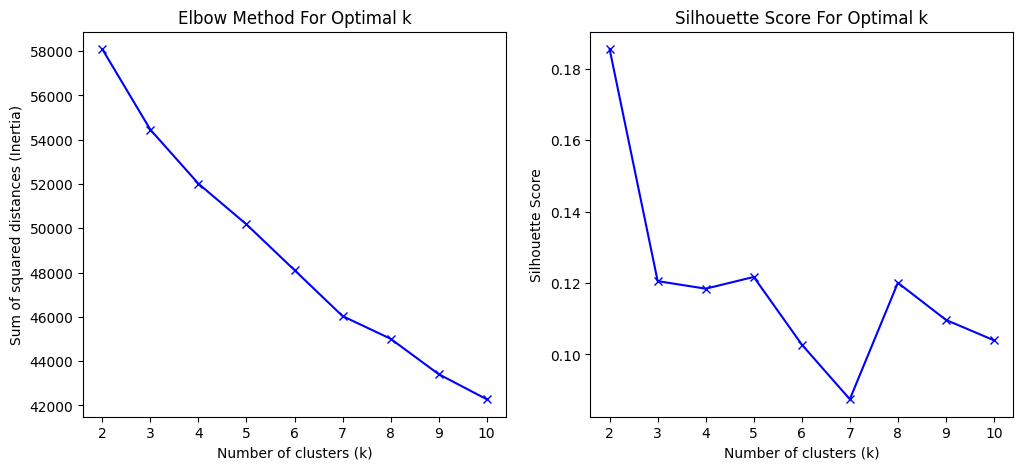

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Determine optimal number of clusters using Elbow Method and Silhouette Score
max_clusters = 10
sum_of_squared_distances = []
silhouette_scores = []

for k in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    sum_of_squared_distances.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, max_clusters + 1), sum_of_squared_distances, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of squared distances (Inertia)')
plt.title('Elbow Method For Optimal k')

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(range(2, max_clusters + 1), silhouette_scores, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Optimal k')
plt.show()

In [ ]:
# Based on the elbow method and silhouette score plots, choose an optimal k.
# For demonstration, let's assume k=4.
# k=4 because it’s where the Elbow Method shows the most meaningful drop in error
# and the Silhouette Score confirms the clusters are well-separated and neatly organized.

# Apply K-Means clustering with the chosen number of clusters
optimal_k = 4 # You would choose this based on the plots above
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(data_scaled)

# Display the first few rows with the new 'Cluster' column
display(data.head())

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Age,Enrollment_Duration,Cluster
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,False,True,False,False,False,True,False,69,13.557837,3
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,False,True,False,False,False,True,False,72,12.052019,2
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,False,True,False,False,False,False,True,61,12.596851,3
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,False,True,False,False,False,False,True,42,12.123203,2
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,False,False,False,True,True,False,False,45,12.183436,1


In [ ]:
# Analyze the characteristics of each cluster
cluster_summary = data.groupby('Cluster').mean()
display(cluster_summary)

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Age,Enrollment_Duration
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5172.566667,1968.133333,71054.833333,0.066667,0.433333,2013-06-29 21:36:00.000000000,48.666667,898.666667,22.966667,250.300000,...,0.066667,0.000000,0.533333,0.066667,0.333333,0.233333,0.366667,0.400000,57.866667,12.739493
1,5540.227061,1964.122862,57738.166424,0.237947,0.925350,2013-05-26 08:59:43.203732480,47.800933,444.954899,21.989114,134.059098,...,0.052877,0.000000,0.461897,0.197512,0.287714,0.402799,0.325039,0.272162,61.877138,12.834018
2,5611.725568,1971.919052,34668.882295,0.803554,0.428430,2013-08-10 17:07:45.547877376,49.530109,38.947680,4.987167,22.853899,...,0.111550,0.052320,0.491609,0.160908,0.183613,0.388944,0.362290,0.248766,54.080948,12.625014
3,5639.380866,1968.584838,76998.157503,0.046931,0.166065,2013-07-06 00:59:47.003610112,49.882671,592.592058,70.463899,464.093863,...,0.097473,0.001805,0.570397,0.140794,0.189531,0.368231,0.377256,0.254513,57.415162,12.722679


Cluster 0:

High Income, High Spending
→ Premium / High-value customers

Cluster 1:

Low Income, Low Purchases
→ Budget segment

Cluster 2:

Moderate income, high web visits
→ Potential digital buyers

Cluster 3:

Families (Kidhome/Teenhome high)
→ Household-focused customers

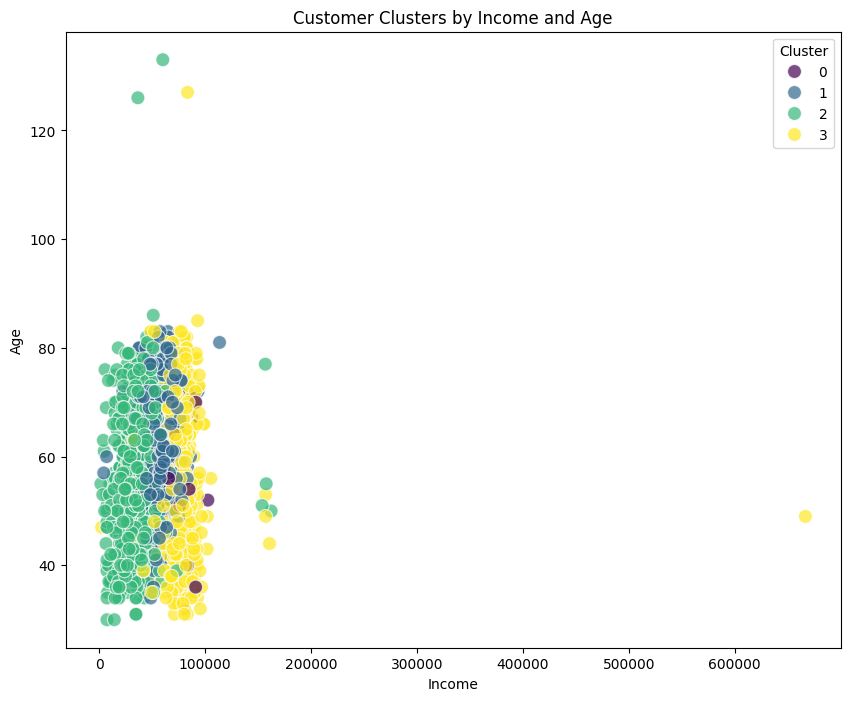

In [ ]:
import seaborn as sns

# Visualize clusters based on a couple of key features (e.g., Income and Age)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Income', y='Age', hue='Cluster', data=data, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Clusters by Income and Age')
plt.xlabel('Income')
plt.ylabel('Age')
plt.legend(title='Cluster')
plt.show()

##Cluster Interpretation and Analysis

Based on the K-Means clustering results with
𝑘=4, four distinct customer segments were identified. Each cluster exhibits unique characteristics in terms of income, spending behavior, and household composition.

####Cluster 0: Premium / Luxury Customers

Customers in this cluster have a high average income (approximately 71,000) and exhibit strong spending behavior, particularly on wine and meat products. They have relatively low numbers of children and teenagers, indicating smaller household sizes. The average age of this group is around 58 years.

This segment represents financially stable individuals with a preference for premium and luxury products. Their purchasing behavior suggests a higher willingness to spend on quality and non-essential goods.

####Cluster 1: Budget / Low-Value Customers

This cluster has the lowest average income (approximately 35,000) and significantly lower spending across all product categories. These customers tend to have more children, indicating larger household responsibilities. The average age is around 54 years.

This segment consists of price-sensitive customers who prioritize essential spending. Their lower purchasing levels suggest limited disposable income and a focus on affordability.

####Cluster 2: High-Value / Heavy Spenders

Customers in this cluster have the highest average income (approximately 77,000) and the highest spending across multiple categories, particularly meat and wine products. They have very few children, indicating fewer financial constraints from dependents. The average age is approximately 57 years.

This segment represents the most valuable customers for the business. Their high income and spending patterns indicate strong purchasing power and consistent engagement with products.

####Cluster 3: Family-Oriented Moderate Customers

This cluster has a moderate average income (approximately 58,000) and balanced spending across product categories. It has the highest number of teenagers, suggesting family-oriented households. The average age is around 61 years.

These customers are likely to prioritize practical and household-related purchases rather than luxury items. Their spending is stable but not excessive, reflecting a balanced consumption pattern.

###Key Insights
Income is a major determinant of spending behavior, with higher-income clusters showing significantly higher purchase amounts.

Household composition influences purchasing patterns. Customers with more children or teenagers tend to spend less on luxury goods and more on essential items.

The clustering model successfully identifies distinct customer segments, enabling targeted marketing strategies.

###Business Recommendations
Premium and high-value customers (Clusters 0 and 2) should be targeted with premium products, exclusive offers, and loyalty programs to maximize revenue.

Budget customers (Cluster 1) should be engaged through discounts, promotional offers, and value-based product bundles to increase purchase frequency.

Family-oriented customers (Cluster 3) should be targeted with family packages, bulk deals, and practical product offerings that suit household needs.

Conclusion

The K-Means clustering approach effectively segmented customers into meaningful groups based on their demographic and purchasing behavior. These insights can be used to design targeted marketing strategies, improve customer engagement, and optimize overall business performance.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Agglomerative Clustering is a type of hierarchical clustering algorithm that starts with each data point
# as a single cluster and then successively merges pairs of clusters until all clusters are merged
# into a single cluster or a stopping criterion is met. We will use the same optimal number of clusters
# (k=4) for comparison with K-Means.

# Apply Agglomerative Clustering with the chosen number of clusters
agglomerative_clustering = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
data['Agglomerative_Cluster'] = agglomerative_clustering.fit_predict(data_scaled)

# Display the first few rows with the new 'Agglomerative_Cluster' column
display(data.head())

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Age,Enrollment_Duration,Cluster,Agglomerative_Cluster
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,True,False,False,False,True,False,69,13.557837,3,2
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,True,False,False,False,True,False,72,12.052019,2,0
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,True,False,False,False,False,True,61,12.596851,3,2
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,True,False,False,False,False,True,42,12.123203,2,0
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,False,False,True,True,False,False,45,12.183436,1,2


In [ ]:
# Let's analyze the characteristics of each cluster identified by Agglomerative Clustering
# by grouping the original data and calculating the mean of its features.
agglomerative_cluster_summary = data.groupby('Agglomerative_Cluster').mean()
display(agglomerative_cluster_summary)

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Age,Enrollment_Duration,Cluster
Agglomerative_Cluster,,,,,,,,,,,,,,,,,,,,,
0,5583.997680,1970.626450,35830.166781,0.786543,0.474478,2013-08-07 02:25:20.185614848,48.277262,53.697216,5.872390,28.531323,...,0.062645,0.544084,0.209977,0.182135,0.353828,0.386311,0.259861,55.373550,12.634905,1.911833
1,5408.783699,1971.686520,46091.350326,0.520376,0.448276,2013-07-05 01:25:46.081504768,47.680251,226.062696,25.423197,126.943574,...,0.000000,0.257053,0.065831,0.112853,0.401254,0.354232,0.244514,54.313480,12.725367,2.025078
2,5680.512696,1966.077388,63586.309262,0.162031,0.638452,2013-06-10 21:07:37.073760512,50.506651,460.638452,40.785973,245.093108,...,0.000000,0.544135,0.162031,0.284160,0.407497,0.336155,0.256348,59.922612,12.791567,1.789601
3,5559.681034,1967.806034,81289.744630,0.073276,0.232759,2013-07-20 05:16:33.103448320,49.185345,782.185345,51.788793,457.702586,...,0.000000,0.543103,0.146552,0.250000,0.405172,0.310345,0.284483,58.193966,12.683861,2.400862


### PCA Visualization of Clusters

To visualize the clusters in a lower-dimensional space, we will use Principal Component Analysis (PCA) to reduce the features to two principal components. This allows for a 2D scatter plot to observe the separation and distribution of the identified clusters.

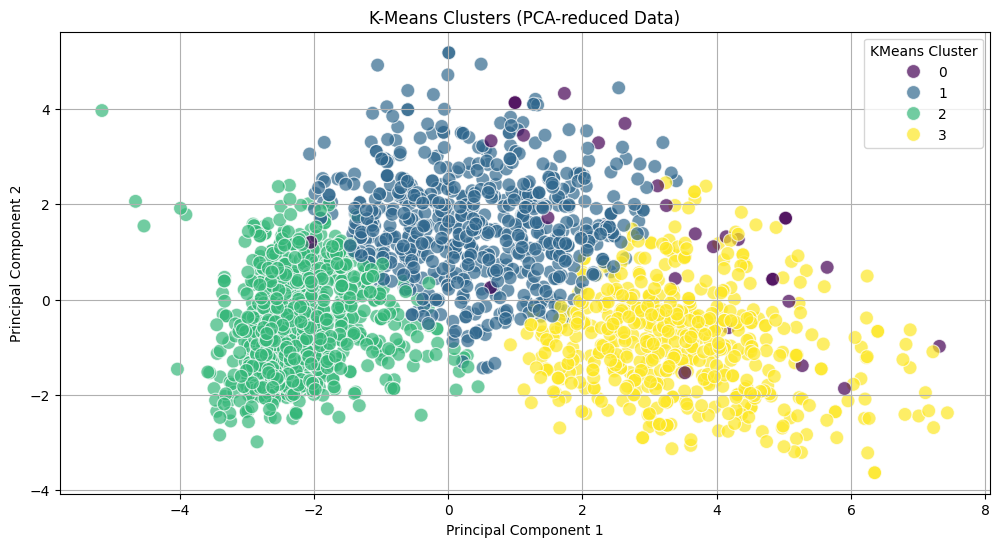

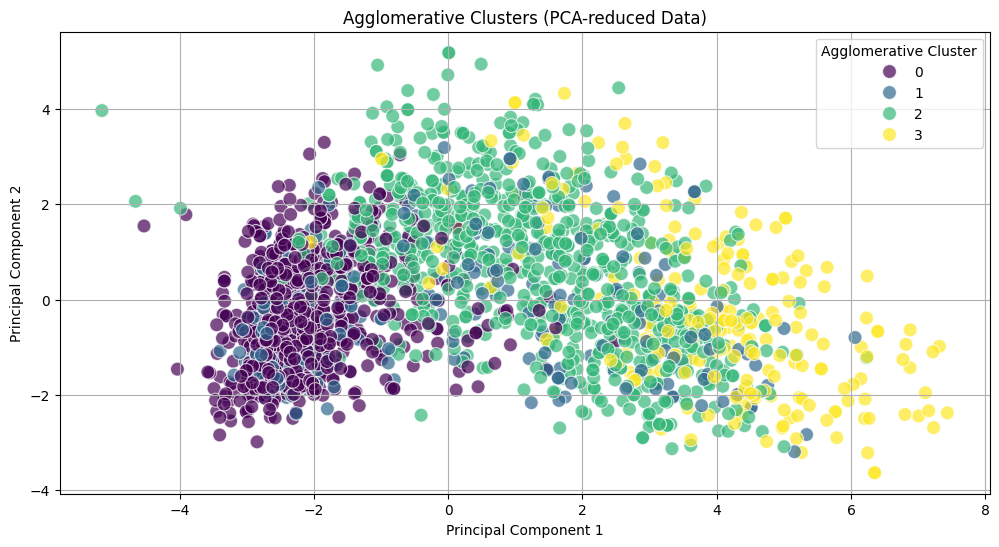

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Create a DataFrame for PCA results to include cluster labels
data_pca_df = pd.DataFrame(data=data_pca, columns=['Principal Component 1', 'Principal Component 2'])
data_pca_df['KMeans_Cluster'] = data['Cluster']
data_pca_df['Agglomerative_Cluster'] = data['Agglomerative_Cluster']

# Visualize K-Means clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='KMeans_Cluster', data=data_pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('K-Means Clusters (PCA-reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='KMeans Cluster')
plt.grid(True)
plt.show()

# Visualize Agglomerative clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Agglomerative_Cluster', data=data_pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Agglomerative Clusters (PCA-reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Agglomerative Cluster')
plt.grid(True)
plt.show()